## PART A

In [4]:
import pandas as pd
df = pd.read_csv("patient_health_records.csv")


In [8]:
missing = df.isnull().mean() * 100
print(missing)


patient_id        0.000000
age               5.000000
gender            5.000000
region            5.000000
bmi               6.711111
blood_pressure    0.000000
cholesterol       5.644444
glucose           5.722222
disease_risk      0.000000
dtype: float64


In [13]:
df['bmi_mean'] = df['bmi'].fillna(df['bmi'].mean())
print(df[['bmi','bmi_mean']].tail())


            bmi   bmi_mean
8995        NaN  25.195802
8996  31.065163  31.065163
8997  25.503454  25.503454
8998  25.276218  25.276218
8999  28.216539  28.216539


In [15]:
df['bmi_median'] = df['bmi'].fillna(df['bmi'].median())
print(df[['bmi','bmi_median']].tail())


            bmi  bmi_median
8995        NaN   25.205915
8996  31.065163   31.065163
8997  25.503454   25.503454
8998  25.276218   25.276218
8999  28.216539   28.216539


In [17]:
mode_region = df['region'].mode()[0]
df['region_imputed'] = df['region'].fillna(mode_region)

print(df[['region','region_imputed']].tail())


     region region_imputed
8995  North          North
8996   East           East
8997  South          South
8998   West           West
8999    NaN          South


In [19]:
mode_gender = df['gender'].mode()[0]
df['gender_imputed'] = df['gender'].fillna(mode_gender)

print(df[['gender','gender_imputed']].tail())

      gender gender_imputed
8995  Female         Female
8996  Female         Female
8997  Female         Female
8998    Male           Male
8999  Female         Female


In [21]:
import numpy as np

df['bmi_flag'] = df['bmi'].isnull().astype(int)

values = df['bmi'].dropna()

df['bmi_random'] = df['bmi']
df.loc[df['bmi'].isnull(), 'bmi_random'] = np.random.choice(values, df['bmi'].isnull().sum())

print(df[['bmi','bmi_flag','bmi_random']].tail())


            bmi  bmi_flag  bmi_random
8995        NaN         1   28.560933
8996  31.065163         0   31.065163
8997  25.503454         0   25.503454
8998  25.276218         0   25.276218
8999  28.216539         0   28.216539


In [25]:
from sklearn.impute import KNNImputer

knn = KNNImputer(n_neighbors=5)

num_cols = ['age','bmi','blood_pressure','cholesterol','glucose']
df_knn = pd.DataFrame(knn.fit_transform(df[num_cols]), columns=num_cols)

print(df_knn.tail())


       age        bmi  blood_pressure  cholesterol     glucose
8995  65.0  19.806373      133.189197   166.785292   92.152551
8996  49.0  31.065163      105.902321   181.396780   63.000151
8997  39.0  25.503454      139.377723   186.080975   98.398411
8998  76.0  25.276218      126.290727   138.533979   74.738220
8999  24.0  28.216539      117.100952   180.110366  138.667813


In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

mice = IterativeImputer(max_iter=10, random_state=0)

df_mice = pd.DataFrame(mice.fit_transform(df[num_cols]), columns=num_cols)
print(df_mice.tail())


       age        bmi  blood_pressure  cholesterol     glucose
8995  65.0  25.105642      133.189197   166.785292   92.152551
8996  49.0  31.065163      105.902321   181.396780   63.000151
8997  39.0  25.503454      139.377723   186.080975   98.398411
8998  76.0  25.276218      126.290727   138.533979   74.738220
8999  24.0  28.216539      117.100952   200.520337  138.667813


## PART B

In [32]:
from scipy.stats import zscore

df_z = df.copy()

df_z['chol_z'] = zscore(df_z['cholesterol'], nan_policy='omit')
df_z['glu_z'] = zscore(df_z['glucose'], nan_policy='omit')

outliers_z = df_z[(abs(df_z['chol_z']) > 3) | (abs(df_z['glu_z']) > 3)]

print(outliers_z.shape)


(780, 17)


In [33]:
df_z_clean = df_z[(abs(df_z['chol_z']) <= 3) & (abs(df_z['glu_z']) <= 3)]
print(df_z_clean.shape)


(7279, 17)


In [34]:
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_iqr = df[(df['bmi'] >= lower) & (df['bmi'] <= upper)]

print(df_iqr.shape)


(7916, 15)


In [35]:
lower = df['bmi'].quantile(0.01)
upper = df['bmi'].quantile(0.99)

df_percentile = df.copy()
df_percentile['bmi'] = df_percentile['bmi'].clip(lower, upper)

print(df_percentile['bmi'].describe())


count    8396.000000
mean       25.195802
std         8.152836
min        -7.295377
25%        21.549256
50%        25.205915
75%        28.836100
max        50.184696
Name: bmi, dtype: float64


In [46]:
from scipy.stats.mstats import winsorize

df_win = df.copy()

df_win['bmi'] = winsorize(df_win['bmi'], limits=[0.01, 0.01])
df_win['cholesterol'] = winsorize(df_win['cholesterol'], limits=[0.01, 0.01])
df_win['glucose'] = winsorize(df_win['glucose'], limits=[0.01, 0.01])

print(df_win.describe())


        patient_id          age          bmi  blood_pressure  cholesterol  \
count  9000.000000  8550.000000  8396.000000     9000.000000  8492.000000   
mean   4500.500000    48.781754    25.195802      123.129320   200.521247   
std    2598.220545    17.858442     8.152836       20.710283    47.794952   
min       1.000000    18.000000    -7.295377       60.484328     9.431406   
25%    2250.750000    34.000000    21.549256      110.240446   178.887803   
50%    4500.500000    49.000000    25.205915      120.838721   200.106496   
75%    6750.250000    64.000000    28.836100      131.672590   221.929966   
max    9000.000000    79.000000    50.184696      194.862188   348.283933   

           glucose  disease_risk     bmi_mean   bmi_median     bmi_flag  \
count  8485.000000   9000.000000  9000.000000  9000.000000  9000.000000   
mean    104.594557      0.503778    25.195802    25.196480     0.067111   
std      28.128565      0.500014     7.874481     7.874482     0.250228   
min   

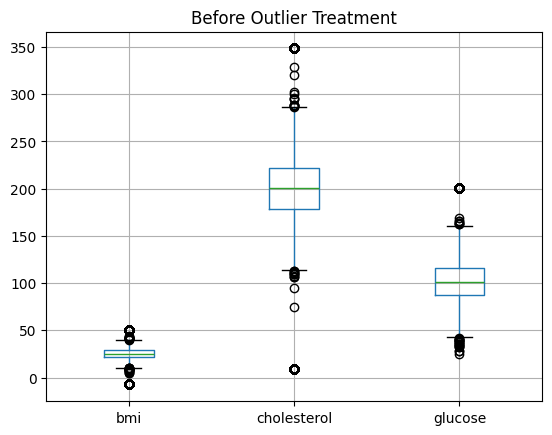

In [48]:
import matplotlib.pyplot as plt

plt.figure()
df[['bmi','cholesterol','glucose']].boxplot()
plt.title("Before Outlier Treatment")
plt.show()


### Before vs After Comparison

| Method        | Shape      |
| ------------- | ---------- |
| Original      | (9000, 9)  |
| Z-score       | (7279, 17) |
| IQR           | (7916, 15) |
| Percentile    | (9000, 9)  |
| Winsorization | (9000, 9)  |


## PART C

In [ ]:
df_final = df.copy()

df_final['bmi'] = df_final['bmi'].fillna(df_final['bmi'].median())
df_final['region'] = df_final['region'].fillna(df_final['region'].mode()[0])
df_final['gender'] = df_final['gender'].fillna(df_final['gender'].mode()[0])

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

mice = IterativeImputer(random_state=0)

num_cols = ['age','cholesterol','glucose']
df_final[num_cols] = mice.fit_transform(df_final[num_cols])


In [38]:
print(df_final.isnull().sum())


patient_id        0
age               0
gender            0
region            0
bmi               0
blood_pressure    0
cholesterol       0
glucose           0
disease_risk      0
bmi_mean          0
bmi_median        0
region_imputed    0
gender_imputed    0
bmi_flag          0
bmi_random        0
dtype: int64


In [39]:
Q1 = df_final['bmi'].quantile(0.25)
Q3 = df_final['bmi'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_final = df_final[(df_final['bmi'] >= lower) & (df_final['bmi'] <= upper)]


In [40]:
from scipy.stats.mstats import winsorize

df_final['cholesterol'] = winsorize(df_final['cholesterol'], limits=[0.01,0.01])
df_final['glucose'] = winsorize(df_final['glucose'], limits=[0.01,0.01])
df_final['blood_pressure'] = winsorize(df_final['blood_pressure'], limits=[0.01,0.01])


In [41]:
print(df_final.shape)


(8482, 15)


In [44]:
df_final.describe()


,patient_id,age,bmi,blood_pressure,cholesterol,glucose,disease_risk,bmi_mean,bmi_median,bmi_flag,bmi_random
count,8482.000000,8482.000000,8482.000000,8482.000000,8482.000000,8482.000000,8482.000000,8482.000000,8482.000000,8482.00000,8482.000000
mean,4509.636289,48.735099,25.109656,123.185116,200.598308,104.627162,0.504598,25.108936,25.109656,0.07121,25.097430
std,2598.331034,17.420724,4.666240,20.611074,46.400356,27.366150,0.500008,4.666226,4.666240,0.25719,5.194115
min,1.000000,18.000000,11.899214,85.756892,9.431406,52.747302,0.000000,11.899214,11.899214,0.00000,-7.295377
25%,2258.250000,34.000000,22.056689,110.245813,180.370607,87.953723,0.000000,22.056689,22.056689,0.00000,21.687808
50%,4511.500000,48.796947,25.205915,120.840913,200.521180,102.896130,1.000000,25.195802,25.205915,0.00000,25.160667
75%,6762.750000,64.000000,28.203049,131.656574,220.394419,115.224085,1.000000,28.203049,28.203049,0.00000,28.496030
max,9000.000000,79.000000,38.477444,194.862188,348.283933,200.924493,1.000000,38.477444,38.477444,1.00000,50.184696


(A) Most Effective Imputation Strategy

Median imputation was most effective for BMI due to presence of outliers.
Most frequent method worked well for categorical variables like gender and region.
MICE algorithm provided the best results for numerical variables by predicting missing values based on relationships between features.

(B) Best Outlier Handling Method

IQR method effectively removed extreme BMI values without excessive data loss.
Winsorization was most suitable for cholesterol and glucose as it capped extreme values without removing records, thus preserving dataset size.

(C) Improvement in Data Quality

- All missing values were successfully handled
- Extreme outliers were removed or capped
- Dataset became more consistent and reliable
- Improved data quality leads to better machine    learning model performance

In [ ]:
!pip install ydata_profiling
import pandas as pd
from ydata_profiling import ProfileReport

# ─── Data Load ───
df = pd.read_csv('patient_health_records.csv')

# ─── Poora EDA report ek line mein! ───
profile = ProfileReport(
    df,
    title="patient_health_records — Full EDA Report",
    explorative=True      # Extra deep analysis
)

# ─── HTML file mein save karo ───
profile.to_file("patient_health_eda_report.html")
print("Report saved! Browser mein kholo.")

# ─── Jupyter Notebook mein directly dikhao ───
profile.to_notebook_iframe()

# ─── Minimal report (bade datasets ke liye faster) ───
profile_minimal = ProfileReport(df, minimal=True)
profile_minimal.to_file("quick_report.html")